In [1]:
!pip -q install qiskit qiskit-aer qiskit-machine-learning pandas numpy scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

In [4]:
uploaded = files.upload()

Saving quantum_input_numeric_loge.tsv to quantum_input_numeric_loge.tsv


In [5]:
df = pd.read_csv('quantum_input_numeric_loge.tsv', sep='\t')
print(df.shape)
display(df.head())
print(df.columns.tolist())

(40, 7)


,species_source,ID,bit_score,full_score,final_rank_score,full_evalue,evalue_neglog10
0,citrus,WP_045714871.1,2508,210.7,2718.7,1.600000e-63,62.795880
1,citrus,WP_011052193.1,2652,NaN,2652.0,NaN,NaN
2,citrus,WP_052456244.1,2612,NaN,2612.0,NaN,NaN
3,citrus,WP_191589000.1,2469,NaN,2469.0,NaN,NaN
4,citrus,WP_011052147.1,1744,38.6,1782.6,1.900000e-09,8.721246


['species_source', 'ID', 'bit_score', 'full_score', 'final_rank_score', 'full_evalue', 'evalue_neglog10']


In [6]:
meta_cols = [c for c in ['species_source', 'ID'] if c in df.columns]
num_cols = [c for c in df.columns if c not in meta_cols]

X = df[num_cols].apply(pd.to_numeric, errors='coerce')
print("Numeric columns:", num_cols)
print(X.isna().sum())

Numeric columns: ['bit_score', 'full_score', 'final_rank_score', 'full_evalue', 'evalue_neglog10']
bit_score           0
full_score          7
final_rank_score    0
full_evalue         7
evalue_neglog10     7
dtype: int64


In [7]:
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols)
display(X_scaled_df.head())

,bit_score,full_score,final_rank_score,full_evalue,evalue_neglog10
0,0.710940,0.872921,0.747914,-0.170154,0.884747
1,0.836166,-1.122354,0.693076,-0.170154,-1.055489
2,0.801381,-1.122354,0.660190,-0.170154,-1.055489
3,0.677025,-1.122354,0.542623,-0.170154,-1.055489
4,0.046547,-0.756822,-0.021701,-0.098550,-0.786024


In [8]:
n_components = min(4, X_scaled_df.shape[1], X_scaled_df.shape[0])
pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled_df)
Xq = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])

print("Quantum input shape:", Xq.shape)
print("Explained variance:", pca.explained_variance_ratio_)
display(Xq.head())

Quantum input shape: (40, 4)
Explained variance: [6.57817781e-01 2.02074894e-01 1.40019440e-01 8.78851533e-05]


,PC1,PC2,PC3,PC4
0,1.617600,-0.074366,-0.127874,0.004540
1,-0.315961,0.356926,1.831604,0.014714
2,-0.349543,0.344200,1.799961,0.015434
3,-0.469598,0.298705,1.686837,0.018007
4,-0.751165,0.074659,0.795042,-0.032396


In [9]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel

feature_map = zz_feature_map(feature_dimension=Xq.shape[1], reps=2)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

kernel_matrix = quantum_kernel.evaluate(x_vec=Xq.to_numpy())

print(kernel_matrix.shape)
display(pd.DataFrame(kernel_matrix).iloc[:5, :5])

(40, 40)


,0,1,2,3,4
0,1.000000,0.422908,0.412037,0.154683,0.052809
1,0.422908,1.000000,0.896855,0.090172,0.037523
2,0.412037,0.896855,1.000000,0.128384,0.019058
3,0.154683,0.090172,0.128384,1.000000,0.007129
4,0.052809,0.037523,0.019058,0.007129,1.000000


In [10]:
pd.DataFrame(kernel_matrix).to_csv('quantum_kernel_matrix.csv', index=False)
files.download('quantum_kernel_matrix.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
labels = []
for i, row in df.iterrows():
    sp = str(row['species_source']) if 'species_source' in df.columns else 'sp'
    gid = str(row['ID']) if 'ID' in df.columns else f'cand_{i}'
    labels.append(f"{sp}|{gid}")

print("labels:", len(labels))
print("kernel size:", kernel_matrix.shape)

labels: 40
kernel size: (40, 40)


In [12]:
if len(labels) == kernel_matrix.shape[0] == kernel_matrix.shape[1]:
    K = pd.DataFrame(kernel_matrix, index=labels, columns=labels)
    display(K.iloc[:5, :5])
else:
    print("Shape mismatch; rebuild input so rows equal columns before labeling.")

,citrus|WP_045714871.1,citrus|WP_011052193.1,citrus|WP_052456244.1,citrus|WP_191589000.1,citrus|WP_011052147.1
citrus|WP_045714871.1,1.000000,0.422908,0.412037,0.154683,0.052809
citrus|WP_011052193.1,0.422908,1.000000,0.896855,0.090172,0.037523
citrus|WP_052456244.1,0.412037,0.896855,1.000000,0.128384,0.019058
citrus|WP_191589000.1,0.154683,0.090172,0.128384,1.000000,0.007129
citrus|WP_011052147.1,0.052809,0.037523,0.019058,0.007129,1.000000


In [13]:
labels = []
for i, row in df.iterrows():
    sp = str(row['species_source']) if 'species_source' in df.columns else 'sp'
    gid = str(row['ID']) if 'ID' in df.columns else f'cand_{i}'
    labels.append(f"{sp}|{gid}")

if len(labels) == kernel_matrix.shape[0] == kernel_matrix.shape[1]:
    K = pd.DataFrame(kernel_matrix, index=labels, columns=labels)
    display(K.iloc[:5, :5])
else:
    raise ValueError(f"Shape mismatch: labels={len(labels)}, kernel={kernel_matrix.shape}")

,citrus|WP_045714871.1,citrus|WP_011052193.1,citrus|WP_052456244.1,citrus|WP_191589000.1,citrus|WP_011052147.1
citrus|WP_045714871.1,1.000000,0.422908,0.412037,0.154683,0.052809
citrus|WP_011052193.1,0.422908,1.000000,0.896855,0.090172,0.037523
citrus|WP_052456244.1,0.412037,0.896855,1.000000,0.128384,0.019058
citrus|WP_191589000.1,0.154683,0.090172,0.128384,1.000000,0.007129
citrus|WP_011052147.1,0.052809,0.037523,0.019058,0.007129,1.000000


In [14]:
K.to_csv('quantum_kernel_matrix_labeled.csv')
files.download('quantum_kernel_matrix_labeled.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

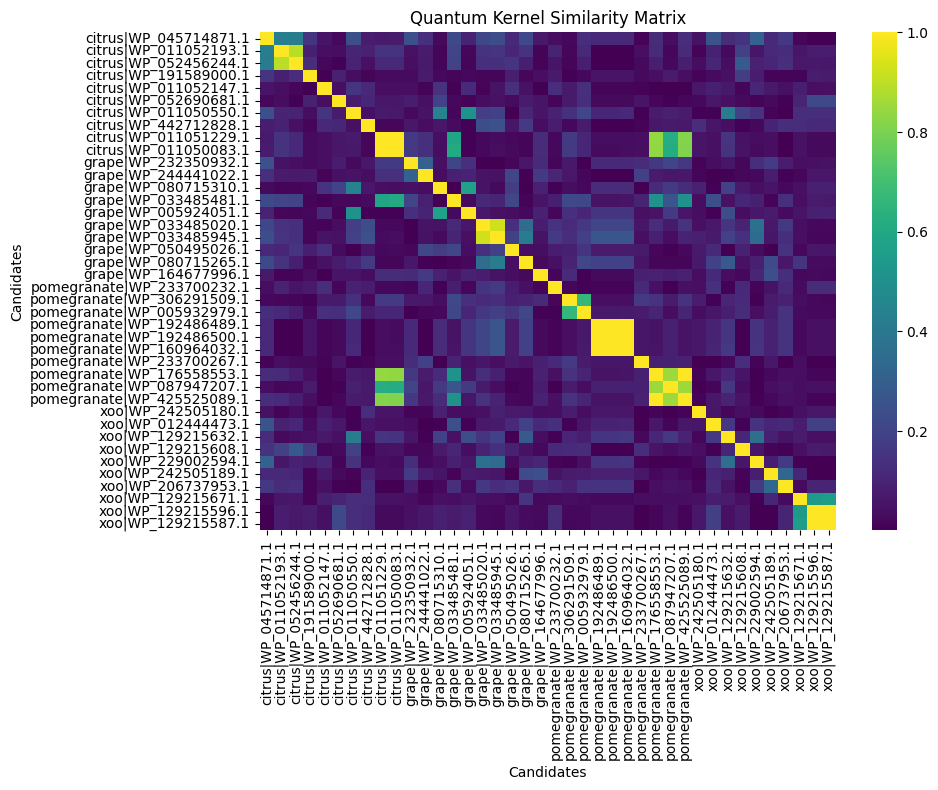

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(K, cmap='viridis')
plt.title('Quantum Kernel Similarity Matrix')
plt.xlabel('Candidates')
plt.ylabel('Candidates')
plt.tight_layout()
plt.show()

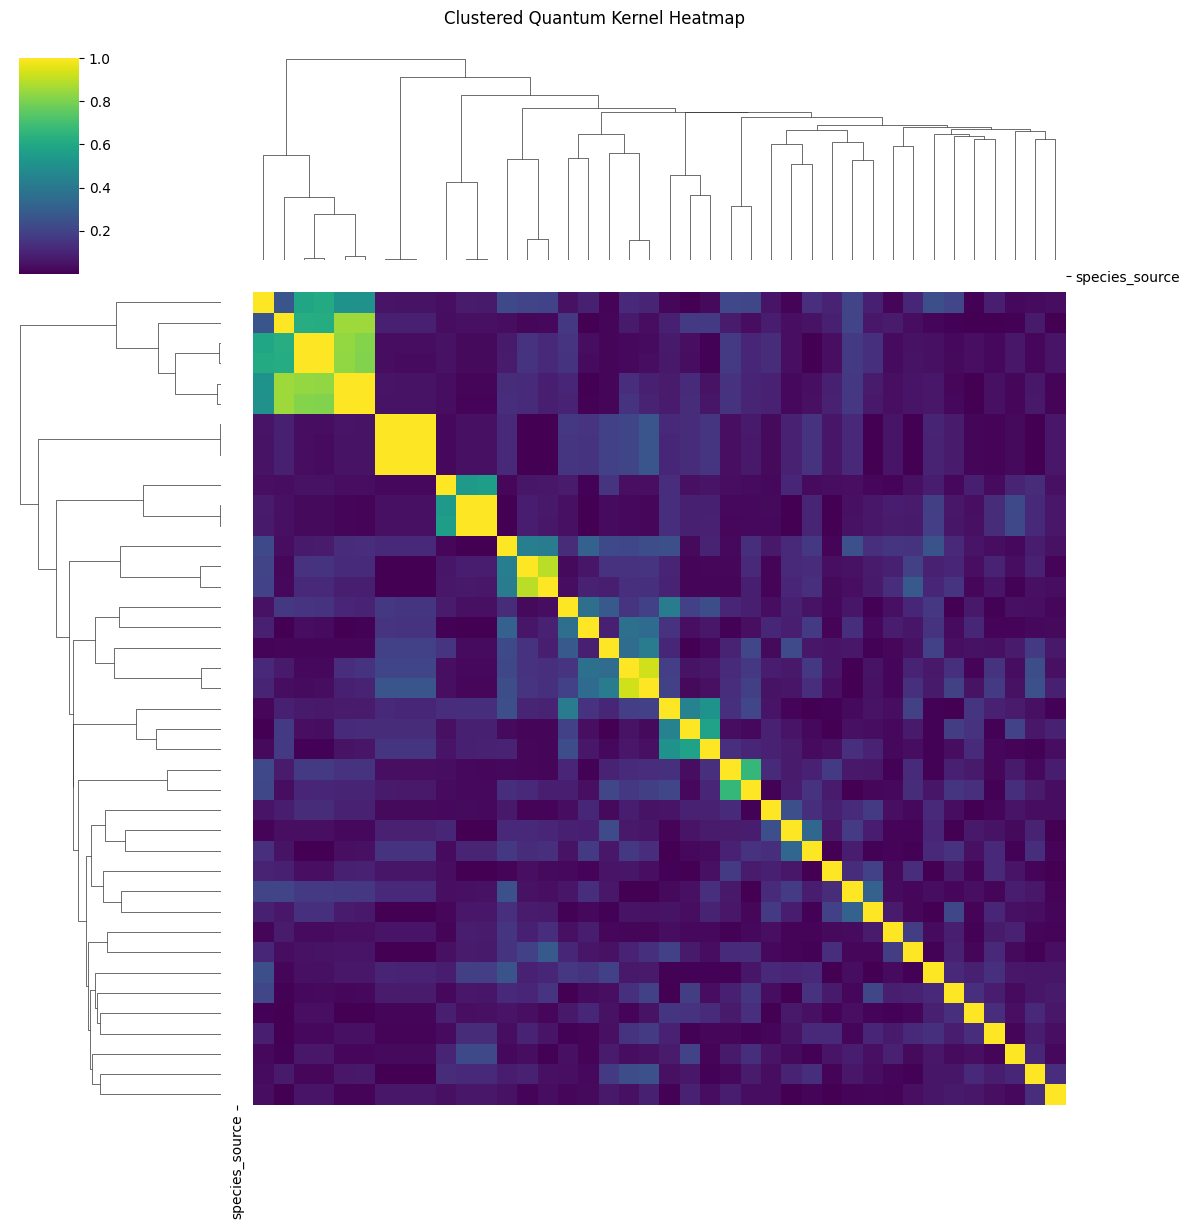

In [16]:
species_palette = {
    'citrus': '#1b9e77',
    'grape': '#7570b3',
    'pomegranate': '#d95f02',
    'xoo': '#e7298a'
}

if 'species_source' in df.columns:
    row_colors = df['species_source'].map(species_palette)
else:
    row_colors = None

g = sns.clustermap(
    K,
    cmap='viridis',
    figsize=(12, 12),
    row_colors=row_colors,
    col_colors=row_colors,
    xticklabels=False,
    yticklabels=False
)

plt.suptitle('Clustered Quantum Kernel Heatmap', y=1.02)
plt.show()

In [17]:
from sklearn.cluster import SpectralClustering

n_clusters = 4

spectral = SpectralClustering(
    n_clusters=n_clusters,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42
)

cluster_labels = spectral.fit_predict(K.to_numpy())

df_clustered = df.copy()
df_clustered['quantum_cluster'] = cluster_labels

display(df_clustered[['species_source', 'ID', 'quantum_cluster']].head(20))

,species_source,ID,quantum_cluster
0,citrus,WP_045714871.1,3
1,citrus,WP_011052193.1,3
2,citrus,WP_052456244.1,3
3,citrus,WP_191589000.1,3
4,citrus,WP_011052147.1,3
5,citrus,WP_052690681.1,0
6,citrus,WP_011050550.1,3
7,citrus,WP_442712828.1,3
8,citrus,WP_011051229.1,2
9,citrus,WP_011050083.1,2


In [18]:
cluster_summary = pd.crosstab(df_clustered['quantum_cluster'], df_clustered['species_source'])
display(cluster_summary)

species_source,citrus,grape,pomegranate,xoo
quantum_cluster,,,,
0,1,0,0,3
1,0,2,3,1
2,2,1,3,0
3,7,7,4,6


In [19]:
df_clustered.to_csv('quantum_clustered_candidates.csv', index=False)
cluster_summary.to_csv('quantum_cluster_species_summary.csv')
files.download('quantum_clustered_candidates.csv')
files.download('quantum_cluster_species_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import pandas as pd

clustered = pd.read_csv('quantum_clustered_candidates.csv')
review = pd.read_csv('top10_candidates_annotation_review_sorted.tsv', sep='\t')

if 'quantum_cluster' not in clustered.columns:
    raise ValueError("quantum_cluster column missing in quantum_clustered_candidates.csv")

join_cols = [c for c in ['species_source', 'ID'] if c in clustered.columns and c in review.columns]
if join_cols != ['species_source', 'ID']:
    raise ValueError("Expected species_source and ID in both files for a safe join")

merged = clustered.merge(review, on=['species_source', 'ID'], how='left', suffixes=('_clustered', '_review'))

print(merged.shape)
display(merged.head())

(40, 16)


,species_source,ID,bit_score_clustered,full_score_clustered,final_rank_score_clustered,full_evalue_clustered,evalue_neglog10,quantum_cluster,Prediction,Protein description,full_evalue_review,description,virulence_literature,bit_score_review,full_score_review,final_rank_score_review
0,citrus,WP_045714871.1,2508,210.7,2718.7,1.600000e-63,62.795880,3,OTHER,calcium-binding protein [Xanthomonas citri],1.600000e-63,RTX,NaN,2508,210.7,2718.7
1,citrus,WP_011052193.1,2652,NaN,2652.0,NaN,NaN,3,OTHER,hypothetical protein [Xanthomonas citri],NaN,NaN,NaN,2652,NaN,2652.0
2,citrus,WP_052456244.1,2612,NaN,2612.0,NaN,NaN,3,OTHER,hypothetical protein [Xanthomonas citri],NaN,NaN,NaN,2612,NaN,2612.0
3,citrus,WP_191589000.1,2469,NaN,2469.0,NaN,NaN,3,OTHER,hypothetical protein [Xanthomonas citri],NaN,NaN,NaN,2469,NaN,2469.0
4,citrus,WP_011052147.1,1744,38.6,1782.6,1.900000e-09,8.721246,3,OTHER,MULTISPECIES: XVIPCD domain-containing protein...,1.900000e-09,"X-Tfes,",NaN,1744,38.6,1782.6


In [23]:
rank_col = next(
    (c for c in ['final_rank_score', 'final_rank_score_review', 'final_rank_score_clustered'] if c in merged.columns),
    None
)

if rank_col is None:
    raise ValueError(f"No rank column found. Available columns: {merged.columns.tolist()}")

for cl in sorted(merged['quantum_cluster'].dropna().unique()):
    sub = merged[merged['quantum_cluster'] == cl].copy()
    sub[rank_col] = pd.to_numeric(sub[rank_col], errors='coerce')
    sub = sub.sort_values(['species_source', rank_col], ascending=[True, False])

    print(f"\n=== quantum_cluster {cl} | n={len(sub)} ===")
    print(sub[['species_source', 'ID', rank_col]].to_string(index=False))


=== quantum_cluster 0 | n=4 ===
species_source             ID  final_rank_score_review
        citrus WP_052690681.1                   1763.2
           xoo WP_129215671.1                   2088.0
           xoo WP_129215596.1                   2085.8
           xoo WP_129215587.1                   2085.6

=== quantum_cluster 1 | n=6 ===
species_source             ID  final_rank_score_review
         grape WP_080715310.1                    903.3
         grape WP_005924051.1                    870.2
   pomegranate WP_192486489.1                   1000.4
   pomegranate WP_192486500.1                   1000.4
   pomegranate WP_160964032.1                    999.4
           xoo WP_129215632.1                   3161.8

=== quantum_cluster 2 | n=6 ===
species_source             ID  final_rank_score_review
        citrus WP_011051229.1                    890.2
        citrus WP_011050083.1                    890.0
         grape WP_033485481.1                    872.9
   pomegranate WP_176

In [24]:
top_per_cluster = (
    merged.sort_values(['quantum_cluster', rank_col], ascending=[True, False])
          .groupby('quantum_cluster', as_index=False)
          .head(5)
)

display(top_per_cluster[['quantum_cluster', 'species_source', 'ID', rank_col]])
top_per_cluster.to_csv('quantum_cluster_top5_genes.tsv', sep='\t', index=False)
files.download('quantum_cluster_top5_genes.tsv')

,quantum_cluster,species_source,ID,final_rank_score_review
37,0,xoo,WP_129215671.1,2088.0
38,0,xoo,WP_129215596.1,2085.8
39,0,xoo,WP_129215587.1,2085.6
5,0,citrus,WP_052690681.1,1763.2
32,1,xoo,WP_129215632.1,3161.8
23,1,pomegranate,WP_192486489.1,1000.4
24,1,pomegranate,WP_192486500.1,1000.4
25,1,pomegranate,WP_160964032.1,999.4
12,1,grape,WP_080715310.1,903.3
8,2,citrus,WP_011051229.1,890.2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
review_cols = [c for c in [
    'quantum_cluster',
    'species_source',
    'ID',
    'Prediction',
    'Protein description',
    'full_evalue',
    'description',
    'virulence_literature',
    'bit_score',
    'full_score',
    rank_col
] if c in merged.columns]

cluster_review = merged[review_cols].sort_values(
    ['quantum_cluster', 'species_source', rank_col],
    ascending=[True, True, False]
)

display(cluster_review.head(20))
cluster_review.to_csv('quantum_cluster_annotation_review.tsv', sep='\t', index=False)
files.download('quantum_cluster_annotation_review.tsv')

,quantum_cluster,species_source,ID,Prediction,Protein description,description,virulence_literature,final_rank_score_review
5,0,citrus,WP_052690681.1,OTHER,putative Ig domain-containing protein [Xanthom...,Putative,NaN,1763.2
37,0,xoo,WP_129215671.1,OTHER,T6SS effector BTH_I2691 family protein [Xantho...,VasX,possible_virulence,2088.0
38,0,xoo,WP_129215596.1,OTHER,T6SS effector BTH_I2691 family protein [Xantho...,VasX,possible_virulence,2085.8
39,0,xoo,WP_129215587.1,OTHER,T6SS effector BTH_I2691 family protein [Xantho...,VasX,possible_virulence,2085.6
12,1,grape,WP_080715310.1,OTHER,serine/threonine-protein kinase [Xanthomonas c...,Protein,NaN,903.3
14,1,grape,WP_005924051.1,OTHER,serine/threonine-protein kinase [Xanthomonas c...,Protein,NaN,870.2
23,1,pomegranate,WP_192486489.1,OTHER,IS5 family transposase [Xanthomonas citri],Transposase,NaN,1000.4
24,1,pomegranate,WP_192486500.1,OTHER,IS5 family transposase [Xanthomonas citri],Transposase,NaN,1000.4
25,1,pomegranate,WP_160964032.1,OTHER,MULTISPECIES: IS5 family transposase [Lysobact...,Transposase,NaN,999.4
32,1,xoo,WP_129215632.1,OTHER,RHS repeat-associated core domain-containing p...,RHS,NaN,3161.8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
species_cluster_summary = pd.crosstab(
    merged['quantum_cluster'],
    merged['species_source']
)

display(species_cluster_summary)
species_cluster_summary.to_csv('quantum_cluster_species_summary_recomputed.csv')
files.download('quantum_cluster_species_summary_recomputed.csv')

species_source,citrus,grape,pomegranate,xoo
quantum_cluster,,,,
0,1,0,0,3
1,0,2,3,1
2,2,1,3,0
3,7,7,4,6


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
best_per_cluster = (
    merged.sort_values(['quantum_cluster', rank_col], ascending=[True, False])
          .groupby('quantum_cluster', as_index=False)
          .head(1)
)

display(best_per_cluster[['quantum_cluster', 'species_source', 'ID', rank_col]])
best_per_cluster.to_csv('quantum_cluster_best_gene_per_cluster.tsv', sep='\t', index=False)
files.download('quantum_cluster_best_gene_per_cluster.tsv')

,quantum_cluster,species_source,ID,final_rank_score_review
37,0,xoo,WP_129215671.1,2088.0
32,1,xoo,WP_129215632.1,3161.8
8,2,citrus,WP_011051229.1,890.2
20,3,pomegranate,WP_233700232.1,7135.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:

final_shortlist = (
    merged.sort_values(['quantum_cluster', rank_col], ascending=[True, False])
          .groupby('quantum_cluster', as_index=False)
          .head(5)
)

keep_cols = [c for c in [
    'quantum_cluster',
    'species_source',
    'ID',
    'Prediction',
    'Protein description',
    'full_evalue',
    'description',
    'virulence_literature',
    'bit_score',
    'full_score',
    rank_col
] if c in final_shortlist.columns]

final_shortlist = final_shortlist[keep_cols].sort_values(
    ['quantum_cluster', 'species_source', rank_col],
    ascending=[True, True, False]
)

display(final_shortlist)
final_shortlist.to_csv('final_cluster_interpreted_shortlist.tsv', sep='\t', index=False)
files.download('final_cluster_interpreted_shortlist.tsv')

,quantum_cluster,species_source,ID,Prediction,Protein description,description,virulence_literature,final_rank_score_review
5,0,citrus,WP_052690681.1,OTHER,putative Ig domain-containing protein [Xanthom...,Putative,NaN,1763.2
37,0,xoo,WP_129215671.1,OTHER,T6SS effector BTH_I2691 family protein [Xantho...,VasX,possible_virulence,2088.0
38,0,xoo,WP_129215596.1,OTHER,T6SS effector BTH_I2691 family protein [Xantho...,VasX,possible_virulence,2085.8
39,0,xoo,WP_129215587.1,OTHER,T6SS effector BTH_I2691 family protein [Xantho...,VasX,possible_virulence,2085.6
12,1,grape,WP_080715310.1,OTHER,serine/threonine-protein kinase [Xanthomonas c...,Protein,NaN,903.3
23,1,pomegranate,WP_192486489.1,OTHER,IS5 family transposase [Xanthomonas citri],Transposase,NaN,1000.4
24,1,pomegranate,WP_192486500.1,OTHER,IS5 family transposase [Xanthomonas citri],Transposase,NaN,1000.4
25,1,pomegranate,WP_160964032.1,OTHER,MULTISPECIES: IS5 family transposase [Lysobact...,Transposase,NaN,999.4
32,1,xoo,WP_129215632.1,OTHER,RHS repeat-associated core domain-containing p...,RHS,NaN,3161.8
8,2,citrus,WP_011051229.1,OTHER,IS4-like element ISXac1 family transposase [Xa...,Transposase,NaN,890.2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
one_per_cluster = (
    merged.sort_values(['quantum_cluster', rank_col], ascending=[True, False])
          .groupby('quantum_cluster', as_index=False)
          .head(1)
)

keep_cols = [c for c in [
    'quantum_cluster',
    'species_source',
    'ID',
    'Prediction',
    'Protein description',
    'full_evalue',
    'description',
    'virulence_literature',
    'bit_score',
    'full_score',
    rank_col
] if c in one_per_cluster.columns]

one_per_cluster = one_per_cluster[keep_cols]

display(one_per_cluster)
one_per_cluster.to_csv('best_gene_per_cluster_interpreted.tsv', sep='\t', index=False)
files.download('best_gene_per_cluster_interpreted.tsv')

,quantum_cluster,species_source,ID,Prediction,Protein description,description,virulence_literature,final_rank_score_review
37,0,xoo,WP_129215671.1,OTHER,T6SS effector BTH_I2691 family protein [Xantho...,VasX,possible_virulence,2088.0
32,1,xoo,WP_129215632.1,OTHER,RHS repeat-associated core domain-containing p...,RHS,NaN,3161.8
8,2,citrus,WP_011051229.1,OTHER,IS4-like element ISXac1 family transposase [Xa...,Transposase,NaN,890.2
20,3,pomegranate,WP_233700232.1,OTHER,LysM domain protein [Xanthomonas citri],RHS,NaN,7135.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
species_view = (
    final_shortlist.sort_values(['species_source', 'quantum_cluster', rank_col], ascending=[True, True, False])
)

display(species_view)
species_view.to_csv('species_view_final_cluster_shortlist.tsv', sep='\t', index=False)
files.download('species_view_final_cluster_shortlist.tsv')

,quantum_cluster,species_source,ID,Prediction,Protein description,description,virulence_literature,final_rank_score_review
5,0,citrus,WP_052690681.1,OTHER,putative Ig domain-containing protein [Xanthom...,Putative,NaN,1763.2
8,2,citrus,WP_011051229.1,OTHER,IS4-like element ISXac1 family transposase [Xa...,Transposase,NaN,890.2
9,2,citrus,WP_011050083.1,OTHER,MULTISPECIES: IS4-like element ISXac1 family t...,Transposase,NaN,890.0
12,1,grape,WP_080715310.1,OTHER,serine/threonine-protein kinase [Xanthomonas c...,Protein,NaN,903.3
13,2,grape,WP_033485481.1,OTHER,helix-turn-helix domain-containing protein [Xa...,IrrE,NaN,872.9
10,3,grape,WP_232350932.1,OTHER,zeta toxin family protein [Xanthomonas citri],Zeta,NaN,2741.2
23,1,pomegranate,WP_192486489.1,OTHER,IS5 family transposase [Xanthomonas citri],Transposase,NaN,1000.4
24,1,pomegranate,WP_192486500.1,OTHER,IS5 family transposase [Xanthomonas citri],Transposase,NaN,1000.4
25,1,pomegranate,WP_160964032.1,OTHER,MULTISPECIES: IS5 family transposase [Lysobact...,Transposase,NaN,999.4
27,2,pomegranate,WP_176558553.1,OTHER,MULTISPECIES: IS3 family transposase [Xanthomo...,Integrase,NaN,859.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>